In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 317.2 kB/s eta 0:02:18
   ---------------------------------------- 0.5/44.0 MB 317.2 kB/s eta 0:02:18
   ---------------------------------------- 0.5/44.0 MB 317.2 kB/s eta 0

In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Concatenate
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
import cv2
import os

In [37]:
data=pd.read_csv("housing_20_jfif.csv")
data.head()

,ImageName,Bedrooms,Bathrooms,Area,Garage,Age,Price
0,house1.jfif,4,2,2517,2,2,552448
1,house2.jfif,2,3,1137,2,7,269803
2,house3.jfif,2,4,2612,0,8,524472
3,house4.jfif,5,1,1407,0,19,335452
4,house5.jfif,5,1,1805,0,18,408638


In [38]:
data.shape

(20, 7)

In [39]:
IMAGE_FOLDER = "House_Images"
images = []
for img_name in data["ImageName"]:
    path = os.path.join(IMAGE_FOLDER, img_name)
    image = cv2.imread(path)
    image = cv2.resize(image, (128, 128))
    image = image / 255.0
    images.append(image)

In [54]:
images = np.array(images)

In [55]:
print(images.shape)
print(X_tab.shape)
print(y.shape)

(20, 128, 128, 3)
(20, 5)
(20,)


In [40]:
X_tab = data.drop(["Price","ImageName"],axis=1)
y = data["Price"]

In [41]:
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

In [42]:
Xtab_train, Xtab_test, Ximg_train, Ximg_test, y_train, y_test = train_test_split(X_tab,images,y,test_size=0.2,random_state=42)

In [45]:
image_input =Input(shape=(128,128,3))
x=Conv2D(32,(3,3),activation="relu")(image_input)
x=MaxPooling2D()(x)
x=Conv2D(64,(3,3),activation="relu")(x)
x=MaxPooling2D()(x)
x=Conv2D(128,(3,3),activation="relu")(x)
x=MaxPooling2D()(x)
x=Flatten()(x)
image_features=Dense(128,activation="relu")(x)

In [46]:
tabular_input = Input(shape=(X_tab.shape[1],))
y1 =Dense(64,activation="relu")(tabular_input)
y1 =Dense(32,activation="relu")(y1)

In [47]:
combined = Concatenate()([image_features,y1])
z =Dense(64,activation="relu")(combined)
z=Dropout(0.3)(z)
output=Dense(1)(z)

In [48]:
model = Model(
    inputs=[image_input,tabular_input],
    outputs=output
)

In [51]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [59]:
print(len(model.inputs))
print(model.inputs)

2
[<KerasTensor shape=(None, 128, 128, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>, <KerasTensor shape=(None, 5), dtype=float32, sparse=False, ragged=False, name=keras_tensor_21>]


In [62]:
Ximg_train = np.array(Ximg_train, dtype=np.float32)
Ximg_test = np.array(Ximg_test, dtype=np.float32)
Xtab_train = np.array(Xtab_train, dtype=np.float32)
Xtab_test = np.array(Xtab_test, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [63]:
print(Ximg_train.shape)
print(Xtab_train.shape)
print(y_train.shape)

(16, 128, 128, 3)
(16, 5)
(16,)


In [64]:
history = model.fit(
    [Ximg_train,Xtab_train],
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 239141601280.0000 - mae: 476735.0938 - val_loss: 258117173248.0000 - val_mae: 481163.0938
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - loss: 239139635200.0000 - mae: 476732.9062 - val_loss: 258111799296.0000 - val_mae: 481157.5625
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 239133736960.0000 - mae: 476726.6562 - val_loss: 258101051392.0000 - val_mae: 481146.4375
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step - loss: 239122825216.0000 - mae: 476715.1562 - val_loss: 258082242560.0000 - val_mae: 481127.0625
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - loss: 239106310144.0000 - mae: 476697.5938 - val_loss: 258049556480.0000 - val_mae: 481093.3125
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - loss: 239072493568.0000 - mae: 476663.0938 - val_loss: 257996357632.0000 - val_mae: 481038.2500
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step - loss: 239009398784.0000 - mae: 476595.2500 - val_loss: 257914

In [57]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 126, 126, 32)      │             896 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 63, 63, 32)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 61, 61, 64)        │          18,496 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 30, 30, 64)        │               0 │ conv2d_4[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 28, 28, 128)       │          73,856 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_5               │ (None, 14, 14, 128)       │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_3 (InputLayer)    │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 25088)             │               0 │ max_pooling2d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │             384 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │       3,211,392 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 32)                │           2,080 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 160)               │               0 │ dense_3[0][0],             │
│                               │                           │                 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 64)                │          10,304 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 3,317,473 (12.66 MB)

 Trainable params: 3,317,473 (12.66 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
predictions = model.predict([Ximg_test,Xtab_test])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


In [66]:
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
print("MAE :",mae)
print("RMSE :",rmse)

MAE : 440767.5625
RMSE : 456754.0421014356


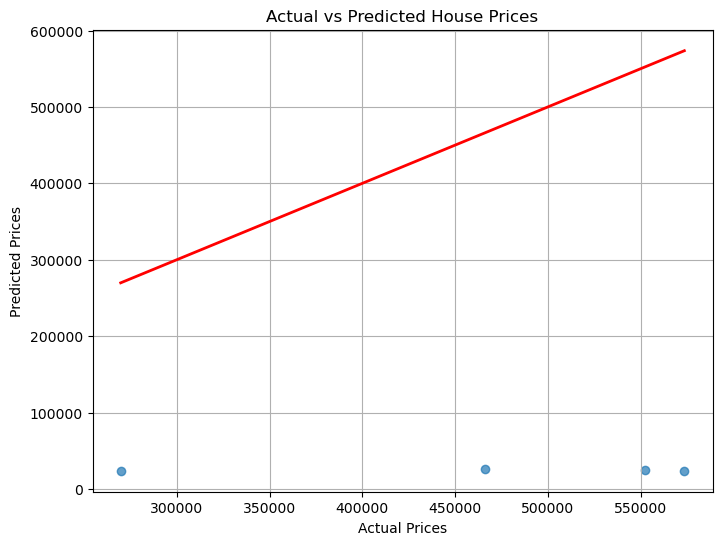

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()

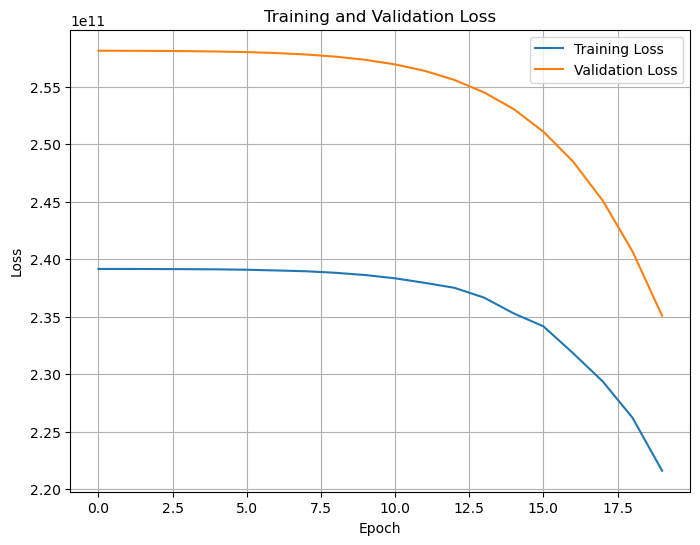

In [71]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()